In [1]:
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import average_precision_score

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)
plt.rcParams["font.sans-serif"] = ["Microsoft JhengHei"]
plt.rcParams["axes.unicode_minus"] = False

# Module A:資料載入與防漏特徵工程

匯入資料

In [2]:
FILE = "./WB_Machine_Error_Event_0722_0728.xlsx"
df = pd.read_excel(FILE)

RUN_KEYS = ["step_id", "lot_id", "equip_type", "equip_id", "recipe_id", "device_name"]
LOT_KEYS = ["lot_id", "step_id"]          # 分析單位：一批貨在一個站別

# 分組鍵的 NaN 會讓 groupby / merge 行為不一致
for c in RUN_KEYS + ["location", "floor"]:
    if c in df.columns:
        df[c] = df[c].fillna("__NA__")

df["eventcount"] = df["eventcount"].fillna(0)
df["start_time"] = pd.to_datetime(df["start_time"])
df["end_time"]   = pd.to_datetime(df["end_time"])

all_events = sorted(df.eventmessage.dropna().unique().tolist())

print(f"原始資料 {df.shape}")
print(f"事件類型 {len(all_events)} 種、批號 {df.lot_id.nunique():,}、"
      f"機台 {df.equip_id.nunique():,}、配方 {df.recipe_id.nunique():,}")

原始資料 (35607, 14)
事件類型 39 種、批號 8,210、機台 2,216、配方 305


In [3]:
# # 對每個 lot × step，檢查 in_qty 的模式
# g = run.groupby(["lot_id","step_id"]).agg(
#     n=("in_qty","size"),
#     in_nunique=("in_qty","nunique"),
#     in_max=("in_qty","max"),
#     in_sum=("in_qty","sum"),
#     ng_max=("ng_qty","max"),
#     ng_sum=("ng_qty","sum"),
#     ng_nunique=("ng_qty","nunique"))
# m = g[g.n > 1].copy()

# # 關鍵檢查：ng 分攤值 × 機台數，是否等於某個整數
# m["ng_implied_total"] = m.ng_max * m.n
# m["is_int"] = np.isclose(m.ng_implied_total, m.ng_implied_total.round(), atol=1e-6)
# print(f"ng_max × n 為整數的比例：{m.loc[m.ng_max>0,'is_int'].mean():.1%}")
# print("  （接近 1.0 → 確認 ng_qty 是總量平均分攤，應用 sum 還原）")

# # in_qty 的模式分類
# m["in_pattern"] = np.select(
#     [m.in_nunique == 1,
#      m.in_nunique == m.n],
#     ["全部相同", "全部不同"], default="部分相同")
# print(f"\nin_qty 模式分布：\n{m.in_pattern.value_counts(normalize=True).round(3).to_string()}")

# # 「部分相同」的案例，重複的那個值佔多少台
# sub = m[m.in_pattern == "部分相同"]
# print(f"\n部分相同的案例數：{len(sub)}")

# # 最關鍵：in_qty 的量級是否合理
# print(f"\nin_max 分布：\n{m.in_max.describe().round(0).to_string()}")
# print(f"\nin_sum 分布：\n{m.in_sum.describe().round(0).to_string()}")

建立run 與 lot兩層資料

In [4]:
# --- run 層級：一個 (站別 × 批號 × 機台 × 配方 × 產品) 一列 ---
run = (df.groupby(RUN_KEYS, as_index=False, dropna=False)
    .agg(start_time  = ("start_time", "min"),
         end_time    = ("end_time", "max"),
         in_qty      = ("in_qty", "max"),      # 同一 run 的多列重複同值
         ng_qty      = ("ng_qty", "max"),
         location    = ("location", "first"),
         floor       = ("floor", "first"),
         total_event = ("eventcount", "sum")))
run["lot_key"] = run.lot_id.astype(str) + "|" + run.step_id.astype(str)
print(f"run 數 {len(run):,}")

# --- 聚合方式：依資料診斷結論寫死 ---
#   in_qty：同 lot×step 內「全部不同」佔 66.9% → 各機台實際分配量 → sum
#   ng_qty：ng_max × n 為整數佔 90.8%          → 總量平均分攤     → sum
IN_QTY_AGG = "sum"
NG_QTY_AGG = "sum"

# --- 事件計數（僅供事後分析，不進預測模型）---
ev_lot = (df.assign(lot_key=df.lot_id.astype(str) + "|" + df.step_id.astype(str))
    .dropna(subset=["eventmessage"])
    .groupby(["lot_key", "eventmessage"], as_index=False)["eventcount"].sum()
    .pivot_table(index="lot_key", columns="eventmessage",
                 values="eventcount", aggfunc="sum", fill_value=0))

# --- lot 層級：分析單位 ---
lot = (run.groupby(LOT_KEYS, as_index=False)
    .agg(lot_key     = ("lot_key", "first"),
         start_time  = ("start_time", "min"),
         end_time    = ("end_time", "max"),
         recipe_id   = ("recipe_id", "first"),
         device_name = ("device_name", "first"),
         equip_type  = ("equip_type", "first"),
         floor       = ("floor", "first"),
         location    = ("location", "first"),
         in_qty      = ("in_qty", IN_QTY_AGG),
         ng_qty      = ("ng_qty", NG_QTY_AGG),
         n_runs      = ("lot_id", "size"),
         n_machines  = ("equip_id", "nunique"),
         total_event = ("total_event", "sum")))

lot = lot.merge(ev_lot.reset_index(), on="lot_key", how="left")
lot[all_events] = lot[all_events].fillna(0)

n0 = len(lot)
lot = lot[lot.in_qty > 0].copy()
print(f"排除 in_qty = 0：{n0 - len(lot)} 筆")

# --- 目標與衍生欄位 ---
lot["dur_h"]   = (lot.end_time - lot.start_time).dt.total_seconds() / 3600
lot["ng_rate"] = lot.ng_qty / lot.in_qty
lot["y_bin"]   = (lot.ng_qty > 0).astype(int)
lot["y_qty"]   = lot.ng_qty
lot["date"]    = lot.start_time.dt.date

per_lot_steps        = run.groupby("lot_id").step_id.nunique()
lot["n_steps"]       = lot.lot_id.map(per_lot_steps)
lot["is_multi_step"] = (lot.n_steps > 1).astype(int)

lot = lot.sort_values("start_time").reset_index(drop=True)

print(f"\n分析單位（lot × step）：{len(lot):,}")
print(f"有報廢的比例：{lot.y_bin.mean():.1%}")
print(f"總投入 {lot.in_qty.sum():,.0f}　總報廢 {lot.ng_qty.sum():,.1f}")
print(f"時長中位數：{lot.dur_h.median():.1f} 小時")
print(f"\n每日單位數：\n{lot.groupby('date').size().to_string()}")
print(f"\nng_rate 分位數：\n{lot.ng_rate.quantile([.5,.9,.99,.999,1.0]).round(5).to_string()}")

run 數 17,179
排除 in_qty = 0：0 筆

分析單位（lot × step）：8,394
有報廢的比例：29.2%
總投入 28,722,394　總報廢 13,247.5
時長中位數：18.0 小時

每日單位數：
date
2026-07-09       1
2026-07-10       2
2026-07-11       1
2026-07-13       1
2026-07-16       2
2026-07-17       2
2026-07-18       2
2026-07-19      13
2026-07-20      98
2026-07-21     849
2026-07-22    1245
2026-07-23    1115
2026-07-24    1131
2026-07-25    1219
2026-07-26    1238
2026-07-27    1109
2026-07-28     366

ng_rate 分位數：
0.500    0.00000
0.900    0.00058
0.990    0.00273
0.999    0.00956
1.000    0.34362


conl:最大值 34.4% 遠高於 p99 的 0.27%——這再次確認報廢分布是「絕大多數為 0 + 少數災難」的混合型，不是常態的製程變異。

每日批數也在這裡暴露了資料邊界：07-09 到 07-20 只有 1 到 98 批，07-21 之後才穩定在千批以上。那些零星的日子是超長滯留批的殘留，後面會被排除。

因果歷史特徵(as-of邏輯)

In [5]:
def asof_prior(target, hist, key, value, out, min_n=3, fallback=None, asof="start_time"):
    """
    對 target 每一筆，只採計 hist 中「在查詢時點之前已完工」的同組紀錄。
    以 end_time 嚴格早於查詢時點為判準，避開同批時間戳相同造成的洩漏。
    #target:要加上特徵的表
    #hist:用來查歷史的表
    #key :分組依據
    #value:要取平均的欄位
    #out:新欄位的名稱
    #min_n:歷史至少要幾筆才採用
    #fallback:歷史不足時的預設值
    #asof:target 中代表「查詢時點」的欄位。預設 start_time（逐批開工時查詢）；
    #     每日批次預測時改傳固定的預測時點欄位，當天稍後才完工的批就不會被看到
    """
    glob = fallback if fallback is not None else hist[value].mean()
    res_v = np.full(len(target), glob, dtype=float)
    res_n = np.zeros(len(target))
    pos = {k: i for i, k in enumerate(target.index)}

    for gkey, h in hist.groupby(key, sort=False):
        tgt = target[target[key] == gkey]
        if tgt.empty:
            continue
        h = h.sort_values("end_time")
        ends = h.end_time.values
        csum = np.concatenate([[0.0], np.cumsum(h[value].to_numpy(dtype=float))])
        n_arr = np.searchsorted(ends, tgt[asof].values, side="left")   # ends < 查詢時點 的筆數
        for idx, n in zip(tgt.index, n_arr):
            res_n[pos[idx]] = n
            if n >= min_n:
                res_v[pos[idx]] = csum[n] / n

    target[out] = res_v
    target[out + "_n"] = res_n
    return target

gp, gr = lot.y_bin.mean(), lot.ng_rate.mean()
hist_lot = lot[["lot_key","recipe_id","device_name","equip_type",
                "start_time","end_time","y_bin","ng_rate"]].copy()

# --- 機台歷史：以 (機台 × lot_key) 為單位 ---
eq_hist = (run.groupby(["equip_id","lot_key"], as_index=False)
    .agg(start_time=("start_time","min"), end_time=("end_time","max"),
         in_qty=("in_qty","max"), ng_qty=("ng_qty","max")))
eq_hist["y_bin"]   = (eq_hist.ng_qty > 0).astype(int)
eq_hist["ng_rate"] = eq_hist.ng_qty / eq_hist.in_qty.clip(lower=1)

LOT_PRIORS = [("recipe_id",   "y_bin",   "prior_recipe_p"),     #該配方下在過去出現報廢的機率
              ("recipe_id",   "ng_rate", "prior_recipe_rate"),  #該配方下在過去的報廢比例
              ("device_name", "y_bin",   "prior_device_p"),     #該產品下在過去出現報廢的機率
              ("equip_type",  "y_bin",   "prior_eqtype_p")]     #該機種下在過去出現報廢的機率

def add_lot_priors(target, asof="start_time", fb_p=None, fb_r=None):
    fb_p = gp if fb_p is None else fb_p
    fb_r = gr if fb_r is None else fb_r
    for key, val, out in LOT_PRIORS:
        target = asof_prior(target, hist_lot, key, val, out,
                            fallback=fb_p if val == "y_bin" else fb_r, asof=asof)
    return target

def eq_prior_table(lot_keys, asof_time=None, fb_p=None, fb_r=None):
    """機台歷史先驗。asof_time=None → 以各機台 run 的開工時間查詢；給定時點 → 一律以該時點查詢"""
    fb_p = gp if fb_p is None else fb_p
    fb_r = gr if fb_r is None else fb_r
    tgt = eq_hist[eq_hist.lot_key.isin(set(lot_keys))].copy()
    asof = "start_time"
    if asof_time is not None:
        tgt["asof_time"] = pd.Timestamp(asof_time)
        asof = "asof_time"
    tgt = asof_prior(tgt, eq_hist, "equip_id", "y_bin",   "eq_prior_p",    fallback=fb_p, asof=asof)
    tgt = asof_prior(tgt, eq_hist, "equip_id", "ng_rate", "eq_prior_rate", fallback=fb_r, asof=asof)
    agg = tgt.groupby("lot_key")[["eq_prior_p","eq_prior_rate","eq_prior_p_n"]].agg(["mean","max"])
    agg.columns = [f"{a}_{b}" for a, b in agg.columns]
    return tgt, agg

lot = add_lot_priors(lot)
eq_tgt, eq_agg = eq_prior_table(lot.lot_key)
lot = lot.merge(eq_agg.reset_index(), on="lot_key", how="left")

no_hist = (eq_tgt.eq_prior_p_n == 0).mean()
USE_EQ_PRIOR = no_hist < 0.5
print(f"機台歷史樣本數中位數 {eq_tgt.eq_prior_p_n.median():.0f}，"
      f"無歷史比例 {no_hist:.1%} → {'納入' if USE_EQ_PRIOR else '排除'}")

機台歷史樣本數中位數 3，無歷史比例 21.4% → 納入


排程特徵與洩漏稽核

In [6]:
# 分派結構（排程時已決定，不構成洩漏）
split = (run.groupby(["lot_key","equip_id"], as_index=False).in_qty.max()
           .groupby("lot_key").in_qty
           .agg(mc_n="size", mc_max="max", mc_sum="sum", mc_std="std"))#mc_n:機台數、mc_max:最大單機投入量、mc_sum:總投入量、mc_std:各機台投入量的標準差
split["split_cv"]  = split.mc_std / (split.mc_sum / split.mc_n).replace(0, np.nan)#變異係數
split["max_share"] = split.mc_max / split.mc_sum.replace(0, np.nan)#最大單機投入量占總量的比例。越接近1代表越依賴單一機台
lot = lot.merge(split[["split_cv","max_share"]].reset_index(), on="lot_key", how="left")#併回去。因為分派方式是開工前排產排出來的，不是跑完之後才知道，所以可以合法當預測特徵。

lot["log_in_qty"] = np.log(lot.in_qty.clip(lower=1))
lot["start_hour"] = lot.start_time.dt.hour
lot["weekday"]    = lot.start_time.dt.weekday
lot["is_night"]   = ((lot.start_hour >= 20) | (lot.start_hour < 8)).astype(int)

#組裝特徵清單與洩漏稽核
FEATURES_NUM = ["log_in_qty","n_runs","n_machines","n_steps","is_multi_step",
                "split_cv","max_share","start_hour","weekday","is_night",
                "prior_recipe_p","prior_recipe_rate","prior_recipe_p_n",
                "prior_device_p","prior_eqtype_p"]
if USE_EQ_PRIOR:
    FEATURES_NUM += ["eq_prior_p_mean","eq_prior_p_max",
                     "eq_prior_rate_mean","eq_prior_rate_max"]
FEATURES_NUM = [c for c in FEATURES_NUM if c in lot.columns]
FEATURES_CAT = ["equip_type","floor","step_id"]#類別特徵維持三種:機種、樓層、站別。recipe_id跟device_name沒有放進類別特徵是因為基數太高，one-hot之後欄位會爆炸，但他們的資訊已經透過prior_recipr_p等歷史特徵間接代入

FORBIDDEN = ["ng_qty","y_bin","y_qty","ng_rate","end_time","dur_h","total_event"] + all_events
leak = [c for c in FEATURES_NUM + FEATURES_CAT if c in FORBIDDEN]
assert not leak, f"洩漏欄位：{leak}"

print(f"數值特徵 {len(FEATURES_NUM)}、類別特徵 {len(FEATURES_CAT)}，洩漏稽核通過")
print(f"\n缺值比例：\n{lot[FEATURES_NUM].isna().mean().round(3).sort_values(ascending=False).head(8).to_string()}")

數值特徵 19、類別特徵 3，洩漏稽核通過

缺值比例：
split_cv         0.338
n_runs           0.000
log_in_qty       0.000
n_machines       0.000
n_steps          0.000
is_multi_step    0.000
max_share        0.000
start_hour       0.000


conl:split_cv缺值為33.8%。那是單機台批號(n_machines=1)標準差算不出來(只有一個數字，無法計算變異)，屬於可預期的。

# Module C : Champion-Challenger 與Walk-Forward 驗證

模型與指標定義

In [7]:
K_PER_DAY = 20

def build_X(tr, te, enc=None, med=None):#因為這xgboost只吃純數值矩陣，但是目前的類別變數(FEATURES_CAT)是以文字呈現，並且FEATURES_NUM裡面的欄位有NaN，所以build_X主要是用來解決這兩件事
    """
    enc / med 為 None 時，以 tr 擬合並回傳；
    傳入既有的 enc / med 則直接沿用，確保欄位一致。
    #enc:將每個類別欄位對應到one-hot encoding
    #med:每個數值欄位的中位數
    """
    if enc is None:
        enc = OneHotEncoder(handle_unknown="ignore", sparse_output=False, min_frequency=20)
        enc.fit(tr[FEATURES_CAT].astype(str))
    if med is None:
        med = tr[FEATURES_NUM].median()

    def _mk(d):#_mk定義成閉包，可以直接抓外層的enc,med，不用當參數傳
        C = enc.transform(d[FEATURES_CAT].astype(str))#套用上面定義好的one-hot encoding規則
        N = d[FEATURES_NUM].fillna(med).to_numpy(dtype=np.float64)
        X = np.hstack([N, C])
        return np.nan_to_num(np.ascontiguousarray(X, dtype=np.float64),
                             posinf=0, neginf=0)

    return _mk(tr), _mk(te), enc, med

def m0_random(tr, te): #m0:純隨機分數，分數介於0~1
    return np.random.default_rng(0).random(len(te))

def m1_recipe_prior(tr, te):#m1:拿module A 算好的prior_recipe_p當分數，不訓練模型，這是真正要打敗的對手
    return te["prior_recipe_p"].fillna(tr.y_bin.mean()).values

def m2_logistic(tr, te):#預測變數y_bin(這批貨會不會出現報廢)
    Xtr, Xte, _, _ = build_X(tr, te)
    mu, sd = Xtr.mean(0), Xtr.std(0) + 1e-9
    m = LogisticRegression(max_iter=3000, class_weight="balanced")
    m.fit((Xtr - mu) / sd, tr.y_bin.to_numpy())
    return m.predict_proba((Xte - mu) / sd)[:, 1]


def m3_gbdt(tr, te):#預測變數y_bin(這批貨會不會出現報廢)
    Xtr, Xte, _, _ = build_X(tr, te)
    ytr = tr.y_bin.to_numpy(dtype=np.int32)
    npos = max(int(ytr.sum()), 1)
    m = xgb.XGBClassifier(
        n_estimators=400, learning_rate=0.05, max_depth=4,
        min_child_weight=5, subsample=0.8, colsample_bytree=0.8,
        reg_lambda=1.0, scale_pos_weight=(len(ytr) - npos) / npos,
        objective="binary:logistic", eval_metric="aucpr",
        tree_method="hist", n_jobs=-1, verbosity=0, random_state=0)
    m.fit(Xtr, ytr)
    return m.predict_proba(Xte)[:, 1]

MODELS  = {"M0 隨機": m0_random, "M1 配方歷史率": m1_recipe_prior,
           "M2 邏輯迴歸": m2_logistic, "M3 GBDT": m3_gbdt}
CHAMPION = "M1 配方歷史率"

def precision_at_k(y, s, k):#模型預測分數最高的前k筆批號裡真正報廢的比例
    return y.values[np.argsort(-s)[:k]].mean() if k > 0 else np.nan

def lift_at_k(y, s, k):#Precision@K/(全體的報廢比例)。回答比隨機挑選好幾倍
    b = y.mean()
    return precision_at_k(y, s, k) / b if b > 0 else np.nan

def loss_capture_at_k(q, s, k):#前k筆批號的報廢量加總，除以當日總報廢量。代表檢查這k批，攔截了多少實際損失
    tot = q.sum()
    return q.values[np.argsort(-s)[:k]].sum() / tot if tot > 0 else np.nan

Walk-Forward 驗證

In [8]:
# === 預測時點與資料切分（修正訓練標籤的時間洩漏）===
# 預測時點 T = 預測日 00:00 + PRED_HOUR。站在 T 這個時間點：
#   訓練集：end_time < T 的批——只有已完工的批，報廢結果才是已知的
#   預測集：start_time 落在 [T, T+1天) 的批
#   在製品（WIP）：start_time < T <= end_time——已開工但結果未知，不可當訓練標籤
PRED_HOUR     = 0      # 例如每天 08:00 出清單就改成 8
FREEZE_PRIORS = True   # True：預測集的歷史先驗凍結在 T（每日批次出清單）
                       # False：沿用各批開工時點（逐批開工時即時評分）

def pred_time(d):
    return pd.Timestamp(d) + pd.Timedelta(hours=PRED_HOUR)

def freeze_priors(te, T):
    """把預測集的歷史先驗改成「只看 T 之前已完工」的版本"""
    te = te.copy()
    known = hist_lot.end_time < T
    fb_p = hist_lot.loc[known, "y_bin"].mean()
    fb_r = hist_lot.loc[known, "ng_rate"].mean()
    te["asof_time"] = T
    te = add_lot_priors(te, asof="asof_time", fb_p=fb_p, fb_r=fb_r)
    if USE_EQ_PRIOR:
        _, agg = eq_prior_table(te.lot_key, asof_time=T, fb_p=fb_p, fb_r=fb_r)
        for c in agg.columns:
            te[c] = te.lot_key.map(agg[c])
    return te.drop(columns="asof_time")

def split_at(d):
    T  = pred_time(d)
    tr = lot[lot.end_time < T]
    te = lot[(lot.start_time >= T) & (lot.start_time < T + pd.Timedelta(days=1))].copy()
    if FREEZE_PRIORS:
        te = freeze_priors(te, T)
    return T, tr, te

def wip_at(T):
    """T 時點仍在站內的批，以及到 T 為止已停留的時數（T 當下就能算，不用 end_time）"""
    w = lot[(lot.start_time < T) & (lot.end_time >= T)].copy()
    w["elapsed_h"] = (T - w.start_time).dt.total_seconds() / 3600
    return w

In [9]:
# === 預期損失模型：校準後機率 × 條件平均量 ===
from sklearn.isotonic import IsotonicRegression

CALIB    = "prior"   # "prior"：解析反推 scale_pos_weight；"isotonic"：時間留出校準；"none"：不校準
CAL_DAYS = 1         # isotonic 用：訓練集最後幾天完工的批拿來校準

def make_clf(ytr):
    npos = max(int(ytr.sum()), 1)
    w = (len(ytr) - npos) / npos
    clf = xgb.XGBClassifier(
        n_estimators=400, learning_rate=0.05, max_depth=4,
        min_child_weight=5, subsample=0.8, colsample_bytree=0.8,
        reg_lambda=1.0, scale_pos_weight=w,
        objective="binary:logistic", eval_metric="aucpr",
        tree_method="hist", n_jobs=-1, verbosity=0, random_state=0)
    return clf, w

def unweight_prob(p, w):
    """scale_pos_weight=w 等於把勝算放大 w 倍：odds' = w × odds
       反推：p = p' / (p' + w(1 − p'))。單調轉換，不改變排序"""
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return p / (p + w * (1 - p))

def isotonic_calibrate(tr, p_full, Xte_full, w):
    """時間留出：用較早完工的批訓練子模型，對最後 CAL_DAYS 天開工且已完工的批擬合校準曲線，
       再套用到全量模型的分數上。樣本不足時退回 prior 反推"""
    t_cal = tr.end_time.max() - pd.Timedelta(days=CAL_DAYS)
    fit_part = tr[tr.end_time < t_cal]
    cal_part = tr[tr.start_time >= t_cal]          # 這些批都在 T 前完工，標籤已知
    if fit_part.y_bin.sum() < 10 or cal_part.y_bin.sum() < 20 or len(cal_part) < 100:
        return unweight_prob(p_full, w)
    Xf, Xc, _, _ = build_X(fit_part, cal_part)
    yf = fit_part.y_bin.to_numpy(dtype=np.int32)
    sub, _ = make_clf(yf)
    sub.fit(Xf, yf)
    iso = IsotonicRegression(y_min=0, y_max=1, out_of_bounds="clip")
    iso.fit(sub.predict_proba(Xc)[:, 1], cal_part.y_bin.to_numpy())
    return iso.predict(p_full)

def fit_expected_loss(tr, te):
    """回傳 p_raw（未校準）、p_cal（校準後）、qty_hat（若報廢的條件平均量）、exp_loss"""
    Xtr, Xte, enc, med = build_X(tr, te)
    ytr = tr.y_bin.to_numpy(dtype=np.int32)
    clf, w = make_clf(ytr)
    clf.fit(Xtr, ytr)
    p_raw = clf.predict_proba(Xte)[:, 1]

    if CALIB == "prior":
        p_cal = unweight_prob(p_raw, w)
    elif CALIB == "isotonic":
        p_cal = isotonic_calibrate(tr, p_raw, Xte, w)
    else:
        p_cal = p_raw

    # 損失模型：Tweedie（log link）直接擬合原始量 → 預測的是條件平均，不是中位數
    # 不用平方誤差：長尾下少數災難批會主導擬合、極不穩定
    pos = tr[tr.y_bin == 1]
    reg = None
    if len(pos) >= 30:
        Xpos, _, _, _ = build_X(pos, te, enc=enc, med=med)
        assert Xpos.shape[1] == Xte.shape[1], f"欄位不一致 {Xpos.shape[1]} vs {Xte.shape[1]}"
        reg = xgb.XGBRegressor(
            n_estimators=300, learning_rate=0.05, max_depth=3,
            min_child_weight=5, subsample=0.8, colsample_bytree=0.8,
            objective="reg:tweedie", tweedie_variance_power=1.5,
            tree_method="hist", n_jobs=-1, verbosity=0, random_state=0)
        reg.fit(Xpos, pos.y_qty.to_numpy(dtype=np.float64))
        qty_hat = reg.predict(Xte).clip(min=0)
    else:
        qty_hat = np.full(len(te), pos.y_qty.mean() if len(pos) else tr.y_qty.mean())

    return {"p_raw": p_raw, "p_cal": p_cal, "qty_hat": qty_hat, "exp_loss": p_cal * qty_hat,
            "clf": clf, "reg": reg, "enc": enc, "med": med, "Xtr": Xtr, "w": w}

def m4_exp_loss(tr, te):#以預期損失排序，放進 walk-forward 與 M1 比較
    return fit_expected_loss(tr, te)["exp_loss"]

MODELS["M4 預期損失"] = m4_exp_loss

In [10]:
MIN_LOTS_PER_DAY = 800

day_size = lot.groupby("date").size()
print("每日批數：")
print(day_size.to_string())

valid_days = sorted(day_size[day_size >= MIN_LOTS_PER_DAY].index)
print(f"\n納入的日子（>= {MIN_LOTS_PER_DAY} 批）：{len(valid_days)} 天")
print(f"  {valid_days[0]} ~ {valid_days[-1]}")
print(f"預測時點：每日 {PRED_HOUR:02d}:00，歷史先驗凍結：{FREEZE_PRIORS}")
MIN_TRAIN_DAYS = 2
records, audit = [], []

for i in range(MIN_TRAIN_DAYS, len(valid_days)):
    T, tr, te = split_at(valid_days[i])#訓練集只含 T 之前已完工的批
    w = wip_at(T)
    audit.append({"date": valid_days[i], "訓練批數": len(tr), "訓練報廢率": tr.y_bin.mean(),
                  "T時未完工(排除)": len(w), "未完工者報廢率": w.y_bin.mean()})
    if len(te) < 20 or te.y_bin.sum() < 3 or tr.y_bin.sum() < 10:
        print(f"[skip] {valid_days[i]}：測試 {len(te)} 筆／正樣本 {te.y_bin.sum()}")
        continue
    k = min(K_PER_DAY, len(te))
    for name, fn in MODELS.items():
        try:
            s = np.asarray(fn(tr, te), dtype=float)
        except Exception as e:
            print(f"[skip] {name} @ {valid_days[i]}: {type(e).__name__}: {e}")
            continue
        records.append({"date": valid_days[i], "model": name, "n_test": len(te), "k": k,
                        "base_rate": te.y_bin.mean(),
                        "PR_AUC": average_precision_score(te.y_bin, s),
                        "P_at_K": precision_at_k(te.y_bin, s, k),
                        "Lift_at_K": lift_at_k(te.y_bin, s, k),
                        "LossCap_at_K": loss_capture_at_k(te.y_qty, s, k)})

# 稽核：被排除的在製批若報廢率明顯較高，代表訓練集偏向「跑得快的批」（右設限偏誤）
print("\n=== 訓練標籤時點稽核 ===")
display(pd.DataFrame(audit).set_index("date").round(3))

wf = pd.DataFrame(records)
if wf.empty:
    print("無有效折數——資料期間過短或正樣本不足")
else:
    display(wf.groupby("model")[["base_rate","PR_AUC","P_at_K",
                                 "Lift_at_K","LossCap_at_K"]].mean().round(3))
    print(f"\n有效折數：{wf.date.nunique()}")
    print("\n=== Golden Rule 晉升檢核 ===")
    for metric in ["P_at_K", "LossCap_at_K"]:
        ch = wf[wf.model == CHAMPION].set_index("date")[metric]
        print(f"\n[{metric}]")
        for m in MODELS:
            if m in (CHAMPION, "M0 隨機"):
                continue
            a = wf[wf.model == m].set_index("date")[metric]
            common = a.index.intersection(ch.index)
            if len(common) == 0:
                continue
            win = a[common] > ch[common]
            print(f"  {m:<14} 勝 {win.sum()}/{len(common)} 折（{win.mean():.0%}）")

    print("\n=== 逐折 LossCap 對照 ===")
    piv = wf.pivot(index="date", columns="model", values="LossCap_at_K")
    piv["M3 − M1"] = piv["M3 GBDT"] - piv["M1 配方歷史率"]
    display(piv.round(3))
    d = piv["M3 − M1"]
    print(f"M3 − M1：平均 {d.mean():+.3f}、中位數 {d.median():+.3f}、"
          f"最小 {d.min():+.3f}、最大 {d.max():+.3f}")
    print("→ 若最大值遠大於其他折，代表 M3 對 M1 的優勢由單一折撐起，結論脆弱")

每日批數：
date
2026-07-09       1
2026-07-10       2
2026-07-11       1
2026-07-13       1
2026-07-16       2
2026-07-17       2
2026-07-18       2
2026-07-19      13
2026-07-20      98
2026-07-21     849
2026-07-22    1245
2026-07-23    1115
2026-07-24    1131
2026-07-25    1219
2026-07-26    1238
2026-07-27    1109
2026-07-28     366

納入的日子（>= 800 批）：7 天
  2026-07-21 ~ 2026-07-27
預測時點：每日 00:00，歷史先驗凍結：True

=== 訓練標籤時點稽核 ===


,訓練批數,訓練報廢率,T時未完工(排除),未完工者報廢率
date,,,,
2026-07-23,1212,0.292,1004,0.383
2026-07-24,2319,0.296,1012,0.404
2026-07-25,3477,0.301,985,0.386
2026-07-26,4698,0.300,983,0.358
2026-07-27,5870,0.296,1049,0.347


,base_rate,PR_AUC,P_at_K,Lift_at_K,LossCap_at_K
model,,,,,
M0 隨機,0.283,0.284,0.27,0.955,0.013
M1 配方歷史率,0.283,0.556,0.75,2.648,0.062
M2 邏輯迴歸,0.283,0.549,0.68,2.394,0.054
M3 GBDT,0.283,0.532,0.73,2.581,0.066
M4 預期損失,0.283,0.494,0.58,2.069,0.056



有效折數：5

=== Golden Rule 晉升檢核 ===

[P_at_K]
  M2 邏輯迴歸        勝 1/5 折（20%）
  M3 GBDT        勝 3/5 折（60%）
  M4 預期損失        勝 1/5 折（20%）

[LossCap_at_K]
  M2 邏輯迴歸        勝 1/5 折（20%）
  M3 GBDT        勝 2/5 折（40%）
  M4 預期損失        勝 2/5 折（40%）

=== 逐折 LossCap 對照 ===


model,M0 隨機,M1 配方歷史率,M2 邏輯迴歸,M3 GBDT,M4 預期損失,M3 − M1
date,,,,,,
2026-07-23,0.012,0.049,0.073,0.048,0.036,-0.002
2026-07-24,0.014,0.064,0.035,0.035,0.048,-0.029
2026-07-25,0.013,0.072,0.046,0.067,0.034,-0.005
2026-07-26,0.011,0.055,0.051,0.092,0.083,0.038
2026-07-27,0.016,0.071,0.063,0.088,0.080,0.017


M3 − M1：平均 +0.004、中位數 -0.002、最小 -0.029、最大 +0.038
→ 若最大值遠大於其他折，代表 M3 對 M1 的優勢由單一折撐起，結論脆弱


In [11]:
# === 預期損失的校準與排序驗證（逐折、樣本外）===
pred_rows = []
for i in range(MIN_TRAIN_DAYS, len(valid_days)):
    T, tr, te = split_at(valid_days[i])
    if len(te) < 20 or te.y_bin.sum() < 3 or tr.y_bin.sum() < 10:
        continue
    r = fit_expected_loss(tr, te)
    pred_rows.append(pd.DataFrame({
        "date": valid_days[i], "y_bin": te.y_bin.to_numpy(), "y_qty": te.y_qty.to_numpy(),
        "p_raw": r["p_raw"], "p_cal": r["p_cal"], "qty_hat": r["qty_hat"], "exp_loss": r["exp_loss"]}))
pr = pd.concat(pred_rows, ignore_index=True)

# (1) 機率校準：每個分箱的平均預測應接近實際命中率
BINS = [0, .05, .1, .2, .3, .4, .5, .6, .8, 1.0001]
def calib_table(col):
    g = pr.groupby(pd.cut(pr[col], BINS, include_lowest=True), observed=True)
    return g.agg(批數=("y_bin","size"), 平均預測=(col,"mean"), 實際命中率=("y_bin","mean"))

print("=== 機率校準：未校準 p_raw ===");            display(calib_table("p_raw").round(3))
print(f"=== 機率校準：校準後 p_cal（{CALIB}）===");  display(calib_table("p_cal").round(3))
brier = lambda p: np.mean((p - pr.y_bin) ** 2)
print(f"Brier：p_raw {brier(pr.p_raw):.4f} → p_cal {brier(pr.p_cal):.4f}（越低越好）")
print(f"預測報廢批數：p_raw {pr.p_raw.sum():.0f}／p_cal {pr.p_cal.sum():.0f}／實際 {pr.y_bin.sum()}")

# (2) 條件量：報廢批的預測平均量應接近實際平均（不是中位數）
pos = pr[pr.y_bin == 1]
print(f"\n報廢批：預測平均量 {pos.qty_hat.mean():.2f}｜實際平均 {pos.y_qty.mean():.2f}"
      f"（實際中位數 {pos.y_qty.median():.2f}）")
qbin = pd.qcut(pos.qty_hat.rank(method="first"), 5, labels=["Q1 低","Q2","Q3","Q4","Q5 高"])
display(pos.groupby(qbin, observed=True).agg(
    批數=("y_qty","size"), 預測平均量=("qty_hat","mean"),
    實際平均量=("y_qty","mean"), 實際最大=("y_qty","max")).round(2))

print("=== 逐日總損失：預期 vs 實際 ===")
display(pr.groupby("date").agg(預期總損失=("exp_loss","sum"), 實際總損失=("y_qty","sum")).round(1))

# (3) 排序：同一折、同一 K 下比較不同排序依據
rk = []
for d, g in pr.groupby("date"):
    k = min(K_PER_DAY, len(g))
    for name, s in [("p_raw", g.p_raw), ("qty_hat", g.qty_hat),
                    ("exp_loss", g.exp_loss), ("理論上限（真實量）", g.y_qty)]:
        rk.append({"date": d, "排序依據": name,
                   "P_at_K": precision_at_k(g.y_bin, s.to_numpy(), k),
                   "LossCap_at_K": loss_capture_at_k(g.y_qty, s.to_numpy(), k)})
rk = pd.DataFrame(rk)
print("=== 排序比較（各折平均）===")
display(rk.groupby("排序依據", sort=False)[["P_at_K","LossCap_at_K"]].mean().round(3))
piv = rk.pivot(index="date", columns="排序依據", values="LossCap_at_K")
piv["exp_loss − p_raw"] = piv["exp_loss"] - piv["p_raw"]
display(piv.round(3))
d = piv["exp_loss − p_raw"]
print(f"exp_loss − p_raw：勝 {(d > 0).sum()}/{len(d)} 折，平均 {d.mean():+.3f}，最小 {d.min():+.3f}")

=== 機率校準：未校準 p_raw ===


,批數,平均預測,實際命中率
p_raw,,,
"(-0.001, 0.05]",138,0.035,0.080
"(0.05, 0.1]",337,0.075,0.077
"(0.1, 0.2]",731,0.147,0.142
"(0.2, 0.3]",696,0.250,0.172
"(0.3, 0.4]",636,0.349,0.204
"(0.4, 0.5]",624,0.449,0.236
"(0.5, 0.6]",515,0.551,0.256
"(0.6, 0.8]",1134,0.703,0.333
"(0.8, 1.0]",1001,0.890,0.597


=== 機率校準：校準後 p_cal（prior）===


,批數,平均預測,實際命中率
p_cal,,,
"(-0.001, 0.05]",559,0.031,0.082
"(0.05, 0.1]",713,0.073,0.149
"(0.1, 0.2]",1083,0.147,0.191
"(0.2, 0.3]",830,0.247,0.222
"(0.3, 0.4]",554,0.350,0.262
"(0.4, 0.5]",505,0.450,0.293
"(0.5, 0.6]",437,0.550,0.368
"(0.6, 0.8]",714,0.692,0.497
"(0.8, 1.0]",417,0.876,0.705


Brier：p_raw 0.2319 → p_cal 0.1877（越低越好）
預測報廢批數：p_raw 2786／p_cal 1955／實際 1646

報廢批：預測平均量 3.93｜實際平均 2.03（實際中位數 1.00）


...

,預期總損失,實際總損失
date,,
2026-07-23,3992.000000,640.8
2026-07-24,1910.000000,761.2
2026-07-25,946.799988,745.5
2026-07-26,510.299988,709.5
2026-07-27,653.099976,489.4


=== 排序比較（各折平均）===


,P_at_K,LossCap_at_K
排序依據,,
p_raw,0.73,0.066
qty_hat,0.46,0.053
exp_loss,0.58,0.056
理論上限（真實量）,1.00,0.306


排序依據,exp_loss,p_raw,qty_hat,理論上限（真實量）,exp_loss − p_raw
date,,,,,
2026-07-23,0.036,0.048,0.019,0.247,-0.012
2026-07-24,0.048,0.035,0.097,0.355,0.012
2026-07-25,0.034,0.067,0.021,0.335,-0.034
2026-07-26,0.083,0.092,0.035,0.357,-0.009
2026-07-27,0.080,0.088,0.090,0.235,-0.008


exp_loss − p_raw：勝 1/5 折，平均 -0.010，最小 -0.034


# Module B:風險排序與P1-P4分級(目的產出今天的檢查清單，資料源截至預測日前的全部資料)

雙模型(clf,reg)輸出預期損失

In [12]:
print(xgb.__version__)

3.4.0


In [13]:
CUT = valid_days[-1]#預測日期(0727)
T_CUT, tr, te = split_at(CUT)#訓練集:T_CUT 前「已完工」的批；預測集:T_CUT 起一天內開工的批
tr = tr.copy()
print(f"預測時點 {T_CUT}｜訓練 {len(tr):,}（正樣本 {tr.y_bin.sum()}，僅含已完工批），預測 {len(te):,}")

res = fit_expected_loss(tr, te)
clf, reg, ENC, MED, Xtr = res["clf"], res["reg"], res["enc"], res["med"], res["Xtr"]
print(f"特徵矩陣 {Xtr.shape}｜scale_pos_weight = {res['w']:.2f}｜校準方式 {CALIB}"
      f"｜損失模型 {'Tweedie' if reg is not None else '歷史平均'}")

out = te.copy()
out["p_raw"]    = res["p_raw"]     # 未校準（僅供對照）
out["p_hat"]    = res["p_cal"]     # 校準後機率
out["qty_hat"]  = res["qty_hat"]   # 若報廢，預期平均量
out["exp_loss"] = res["exp_loss"]  # 預期損失 = p_hat × qty_hat
out = out.sort_values("exp_loss", ascending=False).reset_index(drop=True)
print(f"當日預期總損失 {out.exp_loss.sum():.1f}｜實際總損失 {out.y_qty.sum():.1f}")

預測時點 2026-07-27 00:00:00｜訓練 5,870（正樣本 1740，僅含已完工批），預測 1,109
特徵矩陣 (5870, 39)｜scale_pos_weight = 2.37｜校準方式 prior｜損失模型 Tweedie
當日預期總損失 653.1｜實際總損失 489.4


特徵重要度

In [14]:
feat_names = FEATURES_NUM + list(ENC.get_feature_names_out(FEATURES_CAT))
assert len(feat_names) == Xtr.shape[1]

imp = (pd.Series(clf.feature_importances_, index=feat_names)
         .sort_values(ascending=False).head(15))
print("=== 特徵重要度（前 15）===")
print(imp.round(4).to_string())

=== 特徵重要度（前 15）===
prior_recipe_p                     0.0827
floor_2F                           0.0506
equip_type_IConn Pro Cu            0.0440
floor_3F                           0.0436
equip_type_IConn Pro Cu Plus LA    0.0405
prior_device_p                     0.0362
prior_recipe_rate                  0.0345
n_runs                             0.0329
n_machines                         0.0296
equip_type_UTC-5000 NeoCu          0.0285
max_share                          0.0283
floor_4F                           0.0277
floor_6F                           0.0259
eq_prior_rate_max                  0.0254
equip_type_UTC-2000S               0.0247


P1-P4分級與每日清單

In [15]:
p_hi, loss_hi = out.p_hat.quantile(0.80), out.qty_hat.quantile(0.80)#取得當日預測值的第80百分位當切點。保證每天都有大約20%的批號進入高風險區間。

def grade(r):
    hp, hl = r.p_hat >= p_hi, r.qty_hat >= loss_hi
    if hp and hl:     return "P1 立即調查"#p1代表很有可能出事、而且一出事就嚴重
    if hp:            return "P2 排程改善"#p2代表常出事但每次損失小
    if hl:            return "P3 持續監控"#p3代表不常出事但一出事很貴
    return "P4 暫不行動"#p4代表低機率低損失

out["grade"] = out.apply(grade, axis=1)

print("=== 分級結果 ===")
display(out.groupby("grade").agg(
    批數=("lot_key","size"), 平均機率=("p_hat","mean"),
    平均預估量=("qty_hat","mean"), 實際報廢批=("y_bin","sum"),
    實際命中率=("y_bin","mean"), 實際報廢量=("y_qty","sum")).round(3))

k = min(K_PER_DAY, len(out))
print(f"\n=== 今日 Top {k} 加嚴檢驗清單 ===")
display(out.head(k)[["lot_id","step_id","recipe_id","device_name","in_qty",
                     "n_machines","p_hat","qty_hat","exp_loss","grade"]].round(3))

base = max(out.y_bin.mean(), 1e-9)
print(f"\nPrecision@{k} = {out.head(k).y_bin.mean():.1%}"
      f"（基準 {base:.1%}，Lift {out.head(k).y_bin.mean()/base:.2f}x）")
print(f"報廢量攔截率 = {out.head(k).y_qty.sum()/max(out.y_qty.sum(),1e-9):.1%}")

=== 分級結果 ===


,批數,平均機率,平均預估量,實際報廢批,實際命中率,實際報廢量
grade,,,,,,
P1 立即調查,120,0.716,2.914,72,0.600,176.167
P2 排程改善,102,0.669,1.540,58,0.569,120.833
P3 持續監控,102,0.279,2.419,18,0.176,23.667
P4 暫不行動,785,0.214,1.318,133,0.169,168.750



=== 今日 Top 20 加嚴檢驗清單 ===


,lot_id,step_id,recipe_id,device_name,in_qty,n_machines,p_hat,qty_hat,exp_loss,grade
0,M60747555.00,A42,STSL15BGK310-00-EX-00,66BJY9T1C28LFAS-N3841-3M,7967,4,0.670,10.406,6.975,P1 立即調查
1,M60747658.00,A423,STSM53DGK305-00-UF-03,HH2JFMT3E86BATZT-2DID(M8,4919,3,0.739,6.959,5.145,P1 立即調查
2,M60746312.00,A422,STSL15BGK306-01-EX-02,662JY8T1A28LFAN-N3581-2M,4519,2,0.711,5.854,4.165,P1 立即調查
3,M60746747.00,A422,STSL15BGK306-01-EX-02,662JY8T1A28LFAN-N3581-2M,4558,2,0.619,6.096,3.776,P1 立即調查
4,M60746749.00,A422,STSL15BGK306-01-EX-02,662JY8T1A28LFAN-N3581-2M,4495,2,0.683,5.468,3.734,P1 立即調查
5,M60746474.00,A422,STSL15BGK306-01-EX-02,662JY8T1A28LFAN-N3581-2M,4599,2,0.701,5.289,3.706,P1 立即調查
6,M60747769.00,A42,STSL15BGK310-00-EX-00,66BJY9T1C28LFAS-N3841-3M,5492,3,0.672,5.427,3.648,P1 立即調查
7,M60746475.00,A422,STSL15BGK306-01-EX-02,662JY8T1A28LFAN-N3581-2M,4558,2,0.670,5.354,3.588,P1 立即調查
8,M60747395.00,A423,STSM54FGK301-00-BG-03,HH68LKT5F48BB8T-2DID6M(M8,5237,4,0.736,4.860,3.577,P1 立即調查
9,M60747534.00,A425,STSM52DGK303-00-BG-05,ZKH8LKT3V25BB8N-2DID6M,2290,3,0.869,3.926,3.414,P1 立即調查



Precision@20 = 60.0%（基準 25.3%，Lift 2.37x）
報廢量攔截率 = 8.0%


# Module D:零成本告警與ShadowMode 監控

批號時常告警規則:對0723到0727這五天，每天檢查四個門檻(24,48,72,96)，如果今天把在站內待超過N小時的批號全部拉去檢查，會檢查多少批、攔截多少報廢量?

In [16]:
# 時長規則改在「預測時點 T」評估：對象是 T 當下仍在站內的批，
# 停留時數 = T − start_time，T 當下就能算，不再使用事後才知道的 end_time
rows = []
for i in range(MIN_TRAIN_DAYS, len(valid_days)):
    T = pred_time(valid_days[i])
    w = wip_at(T)
    if len(w) < 20: continue
    tot = w.y_qty.sum()
    for th in [24, 48, 72, 96]:
        f = w.elapsed_h > th
        if f.sum() == 0: continue
        rows.append({"date": valid_days[i], "門檻": th,
                     "在製批數": len(w),
                     "命中批數": int(f.sum()),
                     "佔在製": f.mean(),
                     "命中率": w.loc[f, "y_bin"].mean(),
                     "攔截率": w.loc[f, "y_qty"].sum() / max(tot, 1e-9)})
rule_wf = pd.DataFrame(rows)
display(rule_wf.groupby("門檻")[["在製批數","命中批數","佔在製","命中率","攔截率"]].mean().round(3))
print("註：ng_qty 是完工後的總量，無法區分 T 之前已發生的報廢，攔截率為上限值")

,在製批數,命中批數,佔在製,命中率,攔截率
門檻,,,,,
24,1006.6,135.8,0.135,0.639,0.410
48,1006.6,24.8,0.025,0.804,0.198
72,1006.6,6.4,0.006,0.753,0.129
96,1006.6,3.2,0.003,0.750,0.122


註：ng_qty 是完工後的總量，無法區分 T 之前已發生的報廢，攔截率為上限值


接者測試模型和時常規則能不能互補，三種測試在同一組測試日上比較

In [17]:
# 同一母體（T 時在製批）、同一檢查預算（K 批）下比較模型與規則
RULE_TH = 48
rows = []
for i in range(MIN_TRAIN_DAYS, len(valid_days)):
    d = valid_days[i]
    T = pred_time(d)
    tr = lot[lot.end_time < T]#訓練集：T 前已完工
    w  = wip_at(T)             #在製批的先驗是在各自開工時算的（開工早於 T），不需再凍結
    if len(w) < 20 or w.y_bin.sum() < 3 or tr.y_bin.sum() < 10: continue
    w["score"] = m3_gbdt(tr, w)
    tot = w.y_qty.sum()
    k = min(K_PER_DAY, len(w))

    A = w.nlargest(k, "score")                                  # 模型 Top K
    B = w.nlargest(k, "elapsed_h")                              # 規則：停留最久的 K 批
    r = w[w.elapsed_h > RULE_TH].nlargest(k, "elapsed_h")       # 規則優先（不超過 K）
    C = pd.concat([r, w.drop(index=r.index).nlargest(k - len(r), "score")])
    D = w[w.elapsed_h > RULE_TH]                                # 規則全檢（不限量，僅供參考）

    for name, sub in [(f"模型 Top{k}", A), (f"停留最久 Top{k}", B),
                      (f"規則>{RULE_TH}h+模型補滿", C), (f"規則>{RULE_TH}h 全檢", D)]:
        rows.append({"date": d, "策略": name, "在製批數": len(w),
                     "檢查批數": len(sub), "佔在製": len(sub) / len(w),
                     "命中率": sub.y_bin.mean() if len(sub) else np.nan,
                     "攔截率": sub.y_qty.sum() / max(tot, 1e-9)})
    rows.append({"date": d, "策略": "隨機（期望值）", "在製批數": len(w),
                 "檢查批數": k, "佔在製": k / len(w), "命中率": w.y_bin.mean(),
                 "攔截率": k / len(w)})

cmb = pd.DataFrame(rows)
display(cmb.groupby("策略", sort=False)[["檢查批數","佔在製","命中率","攔截率"]].mean().round(3))

,檢查批數,佔在製,命中率,攔截率
策略,,,,
模型 Top20,20.0,0.020,0.900,0.057
停留最久 Top20,20.0,0.020,0.840,0.191
規則>48h+模型補滿,20.0,0.020,0.850,0.192
規則>48h 全檢,24.8,0.025,0.804,0.198
隨機（期望值）,20.0,0.020,0.376,0.020


Shadow Mode 追蹤與MVSC檢核

In [18]:
ch[common]

date
2026-07-23    0.049415
2026-07-24    0.064375
2026-07-25    0.071986
2026-07-26    0.054501
2026-07-27    0.070833
Name: LossCap_at_K, dtype: float64

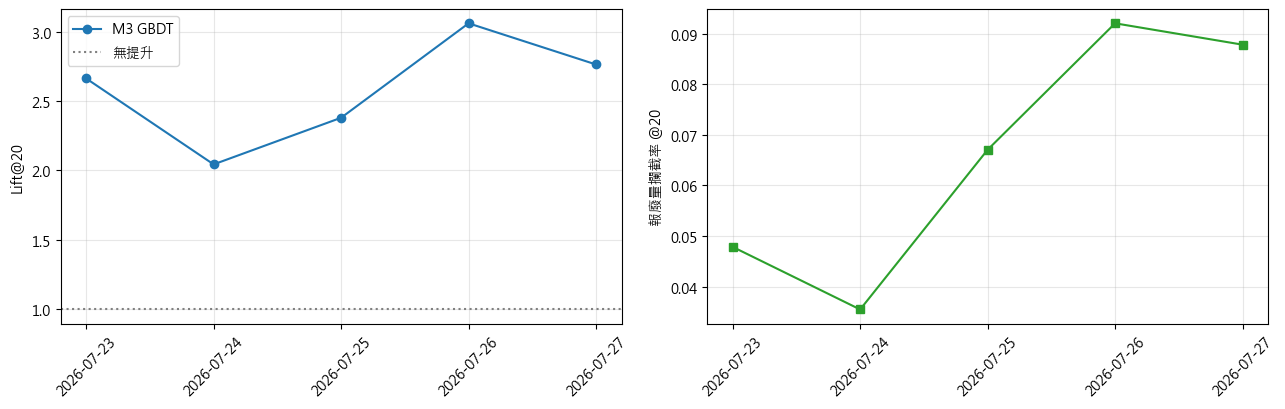

=== MVSC 成功門檻檢核 ===
平均報廢量攔截率 @20：6.6%
Top 20 佔當日批數    ：1.7%
體積 Lift                  ：3.8x   （門檻 > 5）
相對 Champion 的攔截率比值 ：1.08   （門檻 ≥ 1.3）
平均報廢量攔截率               ：6.6%

→ 未達標，維持人工規則


In [19]:
if not wf.empty:
    best = wf[wf.model == "M3 GBDT"].sort_values("date")
    ch   = wf[wf.model == CHAMPION].set_index("date")["P_at_K"]#M1模型的Percision at K

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
    axes[0].plot(best.date.astype(str), best.Lift_at_K, marker="o", label="M3 GBDT")
    # axes[0].axhline(3.0, color="C1", ls="--", label="MVSC 門檻 Lift > 3")
    axes[0].axhline(1.0, color="grey", ls=":", label="無提升")
    axes[0].set_ylabel(f"Lift@{K_PER_DAY}"); axes[0].legend(); axes[0].grid(alpha=.3)
    axes[0].tick_params(axis="x", rotation=45)

    axes[1].plot(best.date.astype(str), best.LossCap_at_K, marker="s", color="C2")
    axes[1].set_ylabel(f"報廢量攔截率 @{K_PER_DAY}"); axes[1].grid(alpha=.3)
    axes[1].tick_params(axis="x", rotation=45)
    plt.tight_layout(); plt.show()

    common = best.set_index("date").index.intersection(ch.index)
    mean_lift = best.Lift_at_K.mean()
    ratio = (best.set_index("date").loc[common,"P_at_K"] / ch[common].replace(0, np.nan)).mean()

    print("=== MVSC 成功門檻檢核 ===")  
    lc = best.LossCap_at_K.mean()
    k_share = K_PER_DAY / best.n_test.mean() # Top K 佔當日的比例
    print(f"平均報廢量攔截率 @{K_PER_DAY}：{lc:.1%}")
    print(f"Top {K_PER_DAY} 佔當日批數    ：{k_share:.1%}")
    print(f"體積 Lift                  ：{lc/k_share:.1f}x   （門檻 > 5）")#攔截率/檢查比例   
    chl = wf[wf.model == CHAMPION].set_index("date")["LossCap_at_K"]
    ratio_lc = (best.set_index("date").loc[common,"LossCap_at_K"]
                / chl[common].replace(0, np.nan)).mean()
    print(f"相對 Champion 的攔截率比值 ：{ratio_lc:.2f}   （門檻 ≥ 1.3）")
    print(f"平均報廢量攔截率               ：{best.LossCap_at_K.mean():.1%}")
    print("\n→", "達標，可進入 Shadow Mode 試運行"
            if (lc / k_share > 5 and ratio_lc >= 1.3)
            else "未達標，維持人工規則")

左圖:Lift_at_K、右圖:報廢量攔截率的逐日變化